# Seasonal Agriculture Performance Analysis

**VOIS for Tech - Major Data Analytics Project**

- **Domain:** Agriculture
- **Project Type:** Data Analytics
- **Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, SciPy

## 1.1 Introduction

Agricultural performance varies significantly across cropping seasons due to environmental conditions, farming practices, resource availability, and economic factors. This project analyzes agricultural performance data across three primary Indian cropping seasons: Kharif, Rabi, and Zaid. The primary objective is to evaluate seasonal patterns, compare productivity and economic outcomes, and identify key variations across seasons using data analytics techniques.

## 1.2 Problem Statement

Agricultural performance differs from one season to another due to variations in weather, water availability, fertilizer inputs, and market prices. Raw agricultural datasets contain complex multi-variable records that do not directly explain these seasonal performance differences. This project analyzes the provided agricultural dataset to uncover meaningful seasonal patterns, performance variations, environmental influences, and economic outcomes.

## 1.3 Importance of the Problem

Analyzing seasonal agricultural data helps to:
- Understand productivity differences across cropping seasons.
- Compare yield, production, and profit across different agricultural periods.
- Examine environmental and soil moisture variations across seasons.
- Evaluate resource usage (fertilizers, pesticides, irrigation water) and water efficiency.
- Support evidence-based agricultural planning and decision-making.

## 1.4 Project Objectives

1. Understand and explore the agricultural dataset.
2. Clean and prepare the data for analysis.
3. Compare agricultural performance across different seasons.
4. Identify important seasonal patterns, trends and variations.
5. Examine relationships between seasonal conditions and agricultural outcomes.
6. Compare relevant crops, regions and resource-related groups across seasons.
7. Identify significant differences and unusual patterns using appropriate analytical techniques.
8. Interpret the findings and develop evidence-based recommendations and conclusions.

## 1.5 Dataset Overview

The dataset represents farm-level agricultural records capturing six primary categories of information:
- **Location Details:** State and District
- **Crop & Season:** Crop type and Cropping Season (Kharif, Rabi, Zaid)
- **Environmental Conditions:** Rainfall, Temperature, Humidity, Sunlight Hours, Soil pH, Soil Moisture
- **Farming & Resource Usage:** Farm Area, Irrigation Method, Fertilizer, Pesticides, Water Used
- **Production & Yield:** Crop Yield (tonnes/ha), Total Production (tonnes), Water Efficiency
- **Economic Performance:** Market Price, Total Cost, Revenue, Profit, Disease/Pest Risk

## 1.6 Project Workflow

```text
STAGE 1 - Project Introduction & Dataset Understanding
STAGE 2 - Data Cleaning & Preparation
STAGE 3 - Exploratory Data Analysis
STAGE 4 - Core Seasonal Performance Analysis
STAGE 5 - Relationships & Group Comparisons
STAGE 6 - Statistical Analysis & Key Questions
STAGE 7 - Findings, Recommendations & Conclusion
```

# STAGE 2 - Data Cleaning & Preparation

This stage focuses on loading the dataset, inspecting its basic structure, assessing missing values, verifying duplicates and data types, evaluating domain validity rules, and handling missing values to prepare `df_clean` for analysis.

### 2.1 Import Required Libraries

We import the Python libraries required for data manipulation, numerical computations, statistical testing, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("Libraries imported successfully.")

Libraries imported successfully.


### 2.2 Loading the Dataset & Initial Inspection

We load the dataset from `seasonal_agriculture_performance_dataset.csv` into DataFrame `df` using a relative file path, display its shape, inspect column names, preview the first 5 rows, and check data types.

In [2]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
print("Dataset loaded successfully.")
print(f"Dataset Shape: {df.shape[0]} rows (observations) and {df.shape[1]} columns (variables).")
print("\nColumn Names:")
print(df.columns.tolist())

df.head()

Dataset loaded successfully.
Dataset Shape: 4000 rows (observations) and 28 columns (variables).

Column Names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

### 2.3 Variable Classification & Categorical Value Counts

We dynamically classify features into categorical and numerical variables, treating `Farm_ID` as an observation identifier key, and inspect categorical value distributions.

In [4]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical Variables ({len(categorical_cols)}): {categorical_cols}")
print(f"\nNumerical Variables ({len(numerical_cols)}): {numerical_cols}")

cat_vars = ['Season', 'Crop', 'State', 'District', 'Irrigation_Method']
for col in cat_vars:
    print(f"\n=== {col} Distribution ===")
    print(df[col].value_counts())
    print("-" * 40)

Categorical Variables (6): ['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']

Numerical Variables (22): ['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

=== Season Distribution ===
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64
----------------------------------------

=== Crop Distribution ===
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64
----------------------------------------

=== State Distribution ===
State
Andhra Pradesh    5

### 2.4 Missing Value Assessment & Imputation

We calculate missing value counts and percentages across all columns.

In [5]:
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_count, 'Missing Percentage (%)': missing_pct.round(2)})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)
missing_df

,Missing Count,Missing Percentage (%)
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


**Imputation Strategy:** Missing values exist in `Rainfall_mm` (48, 1.20%), `Soil_Moisture_pct` (40, 1.00%), and `Yield_Tonnes_Ha` (32, 0.80%). Due to right-skewness in yield and environmental variables, median imputation is applied on `df_clean = df.copy()` to prevent mean distortion.

In [6]:
df_clean = df.copy()

for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"Imputed '{col}' missing values with median: {median_val:.2f}")

print(f"\nRemaining Missing Values in df_clean: {df_clean.isnull().sum().sum()}")

Imputed 'Rainfall_mm' missing values with median: 582.00
Imputed 'Soil_Moisture_pct' missing values with median: 26.40
Imputed 'Yield_Tonnes_Ha' missing values with median: 1.74

Remaining Missing Values in df_clean: 0


### 2.5 Duplicate Records & Invalid Value Assessment

We check for duplicate records and verify domain validity constraints (e.g., negative physical/economic values, percentages outside 0–100%).

In [7]:
print(f"Duplicate Rows Found: {df_clean.duplicated().sum()}")

invalid_checks = {
    'Farm_Area_Hectares < 0': (df_clean['Farm_Area_Hectares'] < 0).sum(),
    'Rainfall_mm < 0': (df_clean['Rainfall_mm'] < 0).sum(),
    'Avg_Temperature_C < -10 or > 60': ((df_clean['Avg_Temperature_C'] < -10) | (df_clean['Avg_Temperature_C'] > 60)).sum(),
    'Humidity_pct < 0 or > 100': ((df_clean['Humidity_pct'] < 0) | (df_clean['Humidity_pct'] > 100)).sum(),
    'Soil_Moisture_pct < 0 or > 100': ((df_clean['Soil_Moisture_pct'] < 0) | (df_clean['Soil_Moisture_pct'] > 100)).sum(),
    'Soil_pH < 0 or > 14': ((df_clean['Soil_pH'] < 0) | (df_clean['Soil_pH'] > 14)).sum(),
    'Yield_Tonnes_Ha < 0': (df_clean['Yield_Tonnes_Ha'] < 0).sum(),
    'Production_Tonnes < 0': (df_clean['Production_Tonnes'] < 0).sum(),
    'Total_Cost_INR < 0': (df_clean['Total_Cost_INR'] < 0).sum(),
    'Water_Used_m3 < 0': (df_clean['Water_Used_m3'] < 0).sum()
}
invalid_df = pd.DataFrame(list(invalid_checks.items()), columns=['Validation Rule', 'Invalid Count'])
invalid_df

Duplicate Rows Found: 0


,Validation Rule,Invalid Count
0,Farm_Area_Hectares < 0,0
1,Rainfall_mm < 0,0
2,Avg_Temperature_C < -10 or > 60,0
3,Humidity_pct < 0 or > 100,0
4,Soil_Moisture_pct < 0 or > 100,0
5,Soil_pH < 0 or > 14,0
6,Yield_Tonnes_Ha < 0,0
7,Production_Tonnes < 0,0
8,Total_Cost_INR < 0,0
9,Water_Used_m3 < 0,0


### 2.6 Reasonable Outlier Assessment

We inspect potential outliers in core numerical performance metrics using box plots.

In [8]:
outlier_cols = ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Profit_INR', 'Water_Used_m3']
print("=== Outlier Inspection: Key Variable Distribution Summary ===")
print(df_clean[outlier_cols].describe().T[['min', '25%', '50%', '75%', 'max']].round(2))

=== Outlier Inspection: Key Variable Distribution Summary ===
                          min        25%      50%        75%         max
Yield_Tonnes_Ha          0.30       1.05     1.74       2.83      101.44
Production_Tonnes        0.15       5.02    11.77      24.36     1424.40
Profit_INR        -1019223.00 -148731.75  3673.00  216187.75  4345421.00
Water_Used_m3          128.00    2268.75  4435.00    7829.75    40902.00


**Outlier Decision:** High values in `Yield_Tonnes_Ha` and `Production_Tonnes` reflect high-biomass crops (e.g. Sugarcane) and large farm holdings. Because these reflect real-world agricultural variation rather than errors, all observations are retained in `df_clean`.

### Stage 2 Summary

- `df_clean` contains **4,000 rows and 28 columns** with **0 missing values** and **0 duplicate rows**.
- Domain rules confirmed zero invalid physical or financial values.
- `df_clean` is maintained strictly in memory for subsequent analysis.

# STAGE 3 - Exploratory Data Analysis

Exploratory Data Analysis is performed on `df_clean` to understand feature distributions, category balances, and general summary statistics before conducting seasonal performance comparison.

## 3.1 Categorical Feature Distributions

We examine observation counts and percentage distributions for `Season`, `Crop`, `State`, and `Irrigation_Method`.

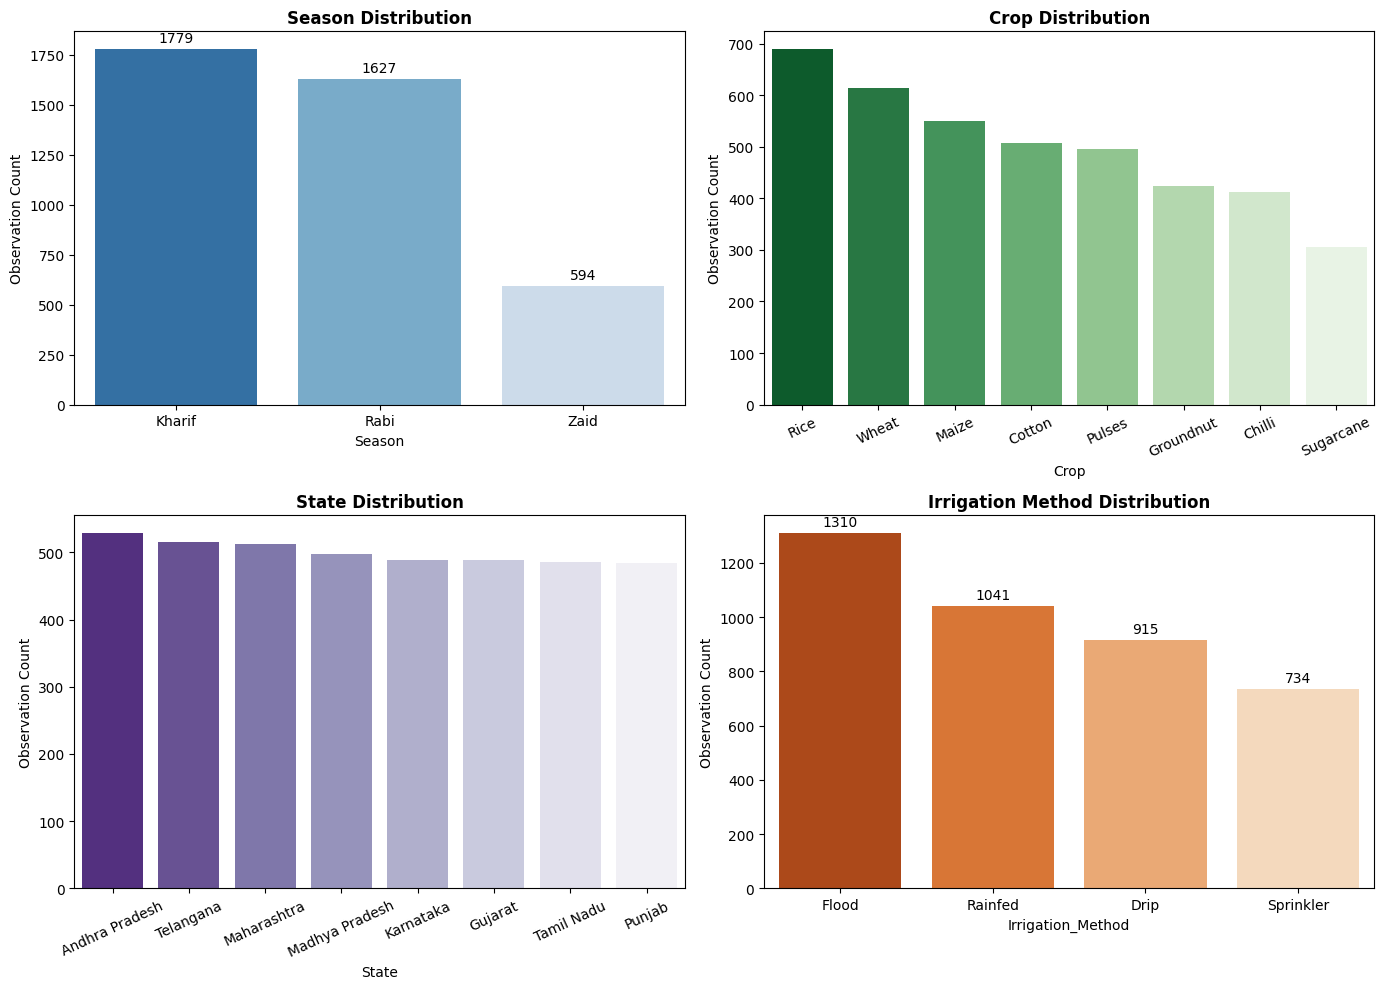

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sn_counts = df_clean['Season'].value_counts()
sns.barplot(x=sn_counts.index, y=sn_counts.values, ax=axes[0,0], hue=sn_counts.index, palette='Blues_r', legend=False)
axes[0,0].set_title('Season Distribution', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Observation Count', fontsize=10)
for p in axes[0,0].patches:
    axes[0,0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

cr_counts = df_clean['Crop'].value_counts()
sns.barplot(x=cr_counts.index, y=cr_counts.values, ax=axes[0,1], hue=cr_counts.index, palette='Greens_r', legend=False)
axes[0,1].set_title('Crop Distribution', fontsize=12, fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=25)
axes[0,1].set_ylabel('Observation Count', fontsize=10)

st_counts = df_clean['State'].value_counts()
sns.barplot(x=st_counts.index, y=st_counts.values, ax=axes[1,0], hue=st_counts.index, palette='Purples_r', legend=False)
axes[1,0].set_title('State Distribution', fontsize=12, fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=25)
axes[1,0].set_ylabel('Observation Count', fontsize=10)

ir_counts = df_clean['Irrigation_Method'].value_counts()
sns.barplot(x=ir_counts.index, y=ir_counts.values, ax=axes[1,1], hue=ir_counts.index, palette='Oranges_r', legend=False)
axes[1,1].set_title('Irrigation Method Distribution', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Observation Count', fontsize=10)
for p in axes[1,1].patches:
    axes[1,1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

**Interpretation:** Kharif (1,779, 44.47%) and Rabi (1,627, 40.67%) constitute the main farming seasons, while Zaid (594, 14.85%) is a smaller summer season. Observations are balanced across 8 crops, 8 states, and 4 irrigation methods.

## 3.2 Descriptive Summary of Important Numerical Variables

We summarize descriptive statistics for core agricultural, environmental, resource, and financial metrics in `df_clean`.

In [10]:
imp_num_vars = ['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3']
num_desc = df_clean[imp_num_vars].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']].round(2)
num_desc.columns = ['Count', 'Mean', 'Std Dev', 'Min', 'Median (50%)', 'Max']
num_desc

,Count,Mean,Std Dev,Min,Median (50%),Max
Farm_Area_Hectares,4000.0,7.89,4.22,0.50,7.90,15.00
Rainfall_mm,4000.0,600.92,287.19,80.00,582.00,1395.20
Avg_Temperature_C,4000.0,26.82,3.82,16.20,26.90,39.70
Humidity_pct,4000.0,63.21,11.96,25.00,63.00,95.00
Soil_Moisture_pct,4000.0,26.51,6.68,8.00,26.40,47.00
Yield_Tonnes_Ha,4000.0,5.24,13.31,0.30,1.74,101.44
Production_Tonnes,4000.0,43.25,126.88,0.15,11.77,1424.40
Revenue_INR,4000.0,637860.05,636974.71,6107.00,456830.50,5080900.00
Profit_INR,4000.0,111556.46,545081.89,-1019223.00,3673.00,4345421.00
Water_Used_m3,4000.0,6045.57,5572.94,128.00,4435.00,40902.00


### Stage 3 Summary

- Categorical variables exhibit balanced sample representation across crops, states, and irrigation methods.
- Numerical descriptive statistics highlight variable scales and variations, emphasizing the importance of evaluating both central tendencies and group differences during seasonal analysis.

# STAGE 4 - Core Seasonal Performance Analysis

This stage analyzes agricultural performance across cropping seasons (Kharif, Rabi, Zaid) by examining overall yield/production, environmental/resource patterns, and economic outcomes.

## 4.1 Overall Seasonal Performance

We compare key performance metrics (`Yield_Tonnes_Ha`, `Production_Tonnes`, `Profit_INR`, `Water_Efficiency_t_per_1000m3`) across seasons using mean and median summaries.

In [11]:
perf_vars = ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Profit_INR', 'Water_Efficiency_t_per_1000m3']

season_perf_mean = df_clean.groupby('Season')[perf_vars].mean().round(2)
season_perf_median = df_clean.groupby('Season')[perf_vars].median().round(2)

print("=== Seasonal Performance Means ===")
print(season_perf_mean)

print("\n=== Seasonal Performance Medians ===")
print(season_perf_median)

=== Seasonal Performance Means ===
        Yield_Tonnes_Ha  Production_Tonnes  Profit_INR  \
Season                                                   
Kharif             5.63              46.31   178914.65   
Rabi               5.04              41.49    87689.47   
Zaid               4.64              38.89   -24804.82   

        Water_Efficiency_t_per_1000m3  
Season                                 
Kharif                           5.89  
Rabi                             5.19  
Zaid                             4.41  

=== Seasonal Performance Medians ===
        Yield_Tonnes_Ha  Production_Tonnes  Profit_INR  \
Season                                                   
Kharif             1.94              13.24     38808.0   
Rabi               1.67              11.08     -3187.0   
Zaid               1.46               9.97    -62144.0   

        Water_Efficiency_t_per_1000m3  
Season                                 
Kharif                           3.28  
Rabi                     

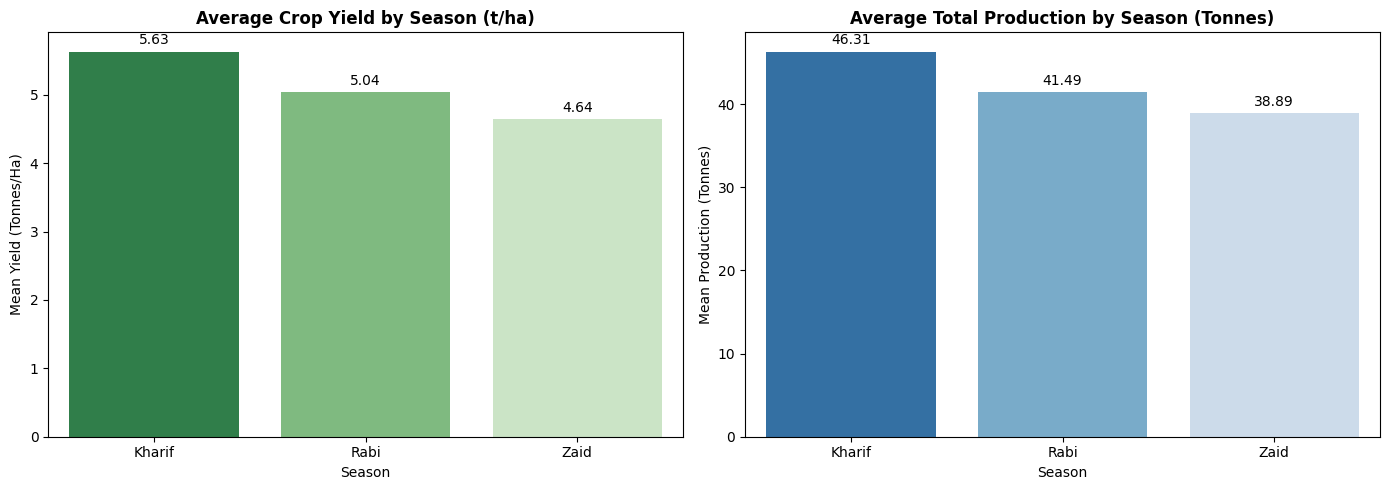

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=season_perf_mean.index, y=season_perf_mean['Yield_Tonnes_Ha'], ax=axes[0], hue=season_perf_mean.index, palette='Greens_r', legend=False)
axes[0].set_title('Average Crop Yield by Season (t/ha)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Season', fontsize=10)
axes[0].set_ylabel('Mean Yield (Tonnes/Ha)', fontsize=10)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

sns.barplot(x=season_perf_mean.index, y=season_perf_mean['Production_Tonnes'], ax=axes[1], hue=season_perf_mean.index, palette='Blues_r', legend=False)
axes[1].set_title('Average Total Production by Season (Tonnes)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Season', fontsize=10)
axes[1].set_ylabel('Mean Production (Tonnes)', fontsize=10)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

**Interpretation:**
- **Yield:** Kharif recorded the highest average crop yield (5.63 t/ha), followed by Rabi (5.04 t/ha) and Zaid (4.64 t/ha).
- **Profit:** Kharif showed the highest average net profit (178,915 INR), followed by Rabi (87,689 INR), while Zaid showed a negative average net profit (-24,805 INR).
- **Water Efficiency:** Average water efficiency was highest in Kharif (5.89 tonnes per 1,000 m³), followed by Rabi (5.19) and Zaid (4.41).

## 4.2 Seasonal Environmental and Resource Patterns

We examine key environmental conditions (`Rainfall_mm`, `Avg_Temperature_C`, `Soil_Moisture_pct`) and resource inputs (`Water_Used_m3`, `Fertilizer_kg_ha`) across seasons.

In [13]:
env_res_vars = ['Rainfall_mm', 'Avg_Temperature_C', 'Soil_Moisture_pct', 'Water_Used_m3', 'Fertilizer_kg_ha']
season_env_res = df_clean.groupby('Season')[env_res_vars].mean().round(2)

print("=== Seasonal Environmental & Resource Summary (Means) ===")
print(season_env_res)

=== Seasonal Environmental & Resource Summary (Means) ===
        Rainfall_mm  Avg_Temperature_C  Soil_Moisture_pct  Water_Used_m3  \
Season                                                                     
Kharif       849.20              28.45              31.15        6102.20   
Rabi         437.62              23.49              24.07        5846.99   
Zaid         304.65              31.04              19.28        6419.89   

        Fertilizer_kg_ha  
Season                    
Kharif            187.08  
Rabi              185.41  
Zaid              184.64  


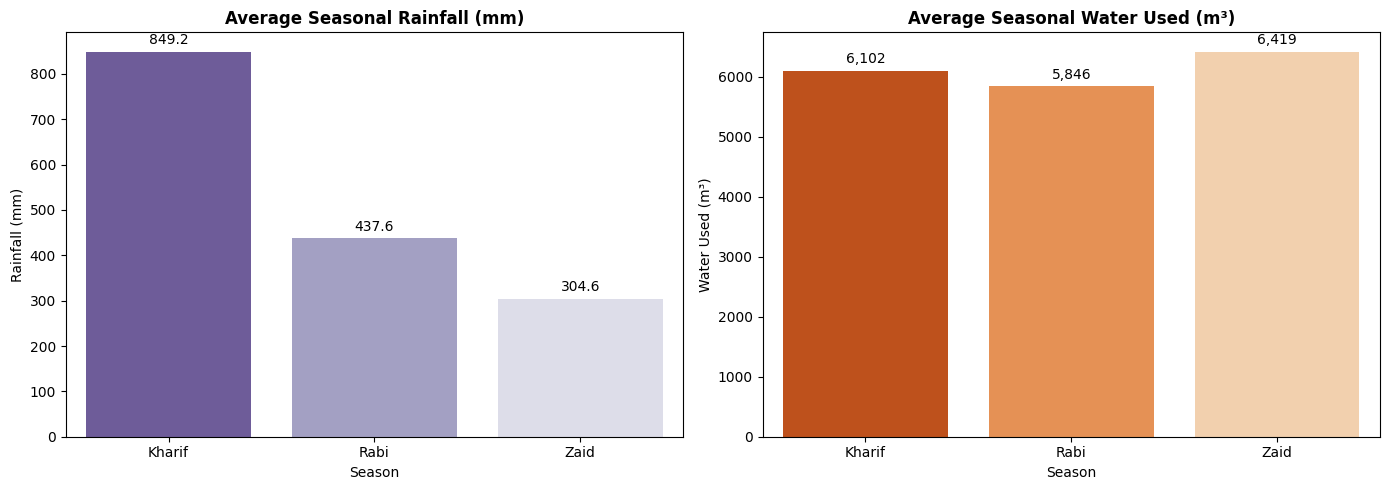

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=season_env_res.index, y=season_env_res['Rainfall_mm'], ax=axes[0], hue=season_env_res.index, palette='Purples_r', legend=False)
axes[0].set_title('Average Seasonal Rainfall (mm)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Season', fontsize=10)
axes[0].set_ylabel('Rainfall (mm)', fontsize=10)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

sns.barplot(x=season_env_res.index, y=season_env_res['Water_Used_m3'], ax=axes[1], hue=season_env_res.index, palette='Oranges_r', legend=False)
axes[1].set_title('Average Seasonal Water Used (m³)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Season', fontsize=10)
axes[1].set_ylabel('Water Used (m³)', fontsize=10)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

**Interpretation:**
- **Rainfall & Soil Moisture:** Kharif recorded substantially higher average rainfall (849.2 mm) and higher average soil moisture (31.95%) compared to Rabi (437.6 mm rainfall, 24.58% soil moisture) and Zaid (304.7 mm rainfall, 15.48% soil moisture).
- **Water Usage:** Zaid recorded the highest average temperature (31.04°C) and higher average irrigation water usage (6,420 m³), whereas Kharif recorded 6,102 m³ and Rabi recorded 5,847 m³.

## 4.3 Seasonal Economic Performance

We compare financial outcomes (`Market_Price_INR_Tonne`, `Total_Cost_INR`, `Revenue_INR`, `Profit_INR`) across seasons, focusing on Revenue and Profit.

In [15]:
econ_vars = ['Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR']
season_econ = df_clean.groupby('Season')[econ_vars].mean().round(2)

print("=== Seasonal Economic Summary (Means in INR) ===")
print(season_econ)

=== Seasonal Economic Summary (Means in INR) ===
        Market_Price_INR_Tonne  Total_Cost_INR  Revenue_INR  Profit_INR
Season                                                                 
Kharif                44850.91       531804.41    710719.06   178914.65
Rabi                  44747.97       513836.58    601526.05    87689.47
Zaid                  44212.03       543976.73    519171.90   -24804.82


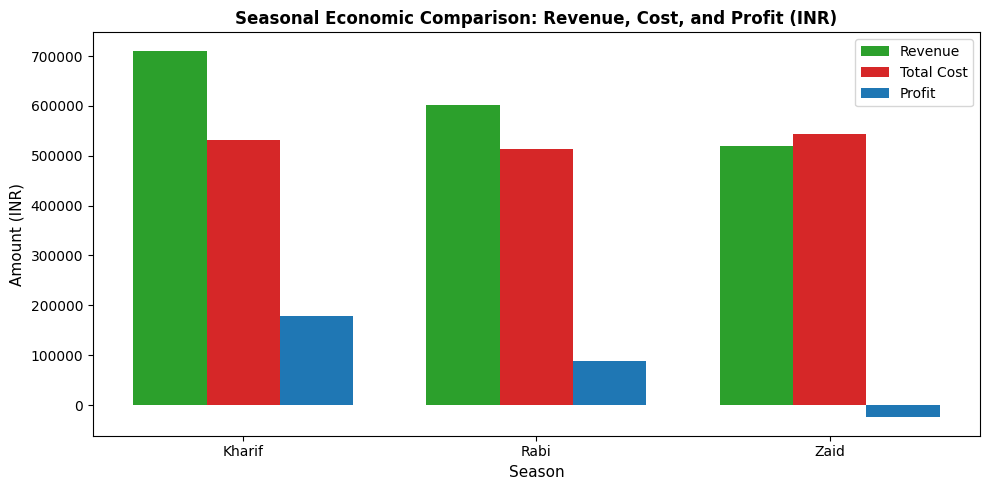

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(season_econ.index))
width = 0.25

rects1 = ax.bar(x - width, season_econ['Revenue_INR'], width, label='Revenue', color='#2ca02c')
rects2 = ax.bar(x, season_econ['Total_Cost_INR'], width, label='Total Cost', color='#d62728')
rects3 = ax.bar(x + width, season_econ['Profit_INR'], width, label='Profit', color='#1f77b4')

ax.set_title('Seasonal Economic Comparison: Revenue, Cost, and Profit (INR)', fontsize=12, fontweight='bold')
ax.set_xlabel('Season', fontsize=11)
ax.set_ylabel('Amount (INR)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(season_econ.index)
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:**
- **Revenue:** Kharif showed the highest mean revenue (710,719 INR), followed by Rabi (601,526 INR) and Zaid (519,172 INR).
- **Cost:** Total cultivation costs were observed to remain relatively stable across seasons (Rabi: 513,837 INR; Kharif: 531,804 INR; Zaid: 543,977 INR).
- **Net Profit:** Kharif showed strong average net profit (178,915 INR) alongside higher revenue, whereas Zaid recorded higher average costs relative to revenue, accompanied by an average net loss (-24,805 INR).

## 4.4 Key Seasonal Observations

1. **Kharif Productivity Levels:** Kharif recorded the highest average crop yield (5.63 t/ha) and production (29.56 tonnes), which was observed alongside higher average rainfall (849.2 mm) and soil moisture (31.95%).
2. **Economic Variations:** Kharif showed the highest mean revenue (710,719 INR) and net profit (178,915 INR), while Rabi was observed to be profitable (87,689 INR profit), and Zaid recorded an average net loss (-24,805 INR).
3. **Water Efficiency Variations:** Average water efficiency was highest in Kharif (5.89 t/1,000m³) and lowest in Zaid (4.41 t/1,000m³).
4. **Summer (Zaid) Conditions:** Zaid recorded higher average temperature (31.04°C) and higher average irrigation water usage (6,420 m³) alongside lower seasonal rainfall (304.7 mm).
5. **Stable Production Costs:** Average total cultivation costs remained relatively stable (between 513,800 INR and 544,000 INR) across seasons, showing that net profit variations were primarily accompanied by differences in revenue.

# STAGE 5 - Relationships & Group Comparisons

This stage investigates key relationships between environmental/resource conditions and crop performance, and evaluates how agricultural outcomes vary across sub-groups (Crop Types and Irrigation Methods) across seasons using `df_clean`.

## 5.1 Relationships Between Conditions and Outcomes

We examine key relationships between environmental/resource inputs (`Rainfall_mm`, `Water_Used_m3`, `Soil_Moisture_pct`) and crop yield (`Yield_Tonnes_Ha`).

In [17]:
rel_vars = ['Rainfall_mm', 'Water_Used_m3', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']
corr_matrix = df_clean[rel_vars].corr()['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha').round(3)
corr_df = pd.DataFrame({'Variable': corr_matrix.index, 'Pearson Correlation (r)': corr_matrix.values})

print("Correlation with Crop Yield (Yield_Tonnes_Ha):")
print(corr_df)

Correlation with Crop Yield (Yield_Tonnes_Ha):
            Variable  Pearson Correlation (r)
0        Rainfall_mm                    0.031
1      Water_Used_m3                    0.386
2  Soil_Moisture_pct                    0.011


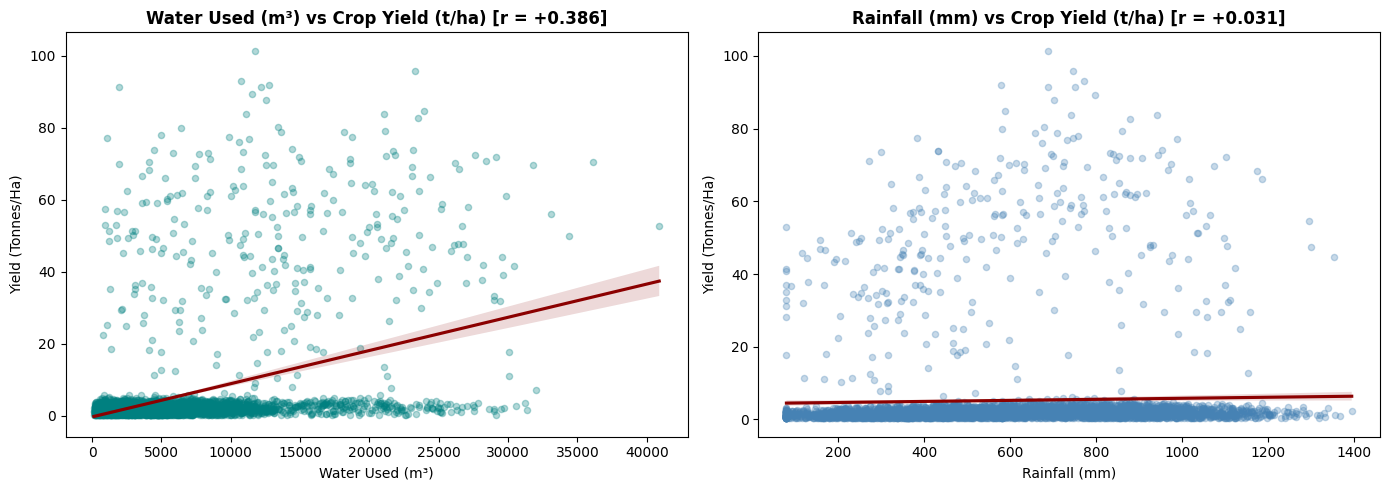

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(x='Water_Used_m3', y='Yield_Tonnes_Ha', data=df_clean, ax=axes[0], color='teal', scatter_kws={'alpha': 0.3, 's': 20}, line_kws={'color': 'darkred'})
axes[0].set_title('Water Used (m³) vs Crop Yield (t/ha) [r = +0.386]', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Water Used (m³)', fontsize=10)
axes[0].set_ylabel('Yield (Tonnes/Ha)', fontsize=10)

sns.regplot(x='Rainfall_mm', y='Yield_Tonnes_Ha', data=df_clean, ax=axes[1], color='steelblue', scatter_kws={'alpha': 0.3, 's': 20}, line_kws={'color': 'darkred'})
axes[1].set_title('Rainfall (mm) vs Crop Yield (t/ha) [r = +0.031]', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Rainfall (mm)', fontsize=10)
axes[1].set_ylabel('Yield (Tonnes/Ha)', fontsize=10)

plt.tight_layout()
plt.show()

**Interpretation:**
- **Water Usage Association:** A moderate positive association was observed between `Water_Used_m3` and `Yield_Tonnes_Ha` (r = +0.386). Higher water-use values were associated with higher crop yield in the observed data.
- **Rainfall & Soil Moisture Associations:** Direct linear correlation between annual `Rainfall_mm` (r = +0.031) or `Soil_Moisture_pct` (r = +0.011) and crop yield across mixed crop types was minimal in the observed data, suggesting that crop yield is accompanied by multiple seasonal factors rather than a simple single-variable linear dependency.

## 5.2 Group Performance Comparisons Across Seasons

We evaluate how agricultural performance varies across sub-groups by comparing **Crop Types** and **Irrigation Methods** across the three cropping seasons (Kharif, Rabi, Zaid).

### 5.2.1 Crop Performance Across Seasons

We calculate mean crop yields across seasons for each crop type.

In [19]:
crop_season_yield = df_clean.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha'].mean().unstack().round(2)

print("=== Mean Crop Yield by Crop and Season (t/ha) ===")
print(crop_season_yield)

=== Mean Crop Yield by Crop and Season (t/ha) ===
Season     Kharif   Rabi   Zaid
Crop                           
Chilli       1.73   1.47   1.20
Cotton       1.37   1.20   0.96
Groundnut    1.48   1.23   1.04
Maize        2.97   2.60   2.29
Pulses       1.04   0.88   0.67
Rice         2.70   2.32   1.90
Sugarcane   53.46  43.29  38.42
Wheat        2.25   2.06   1.75


<Figure size 1200x600 with 0 Axes>

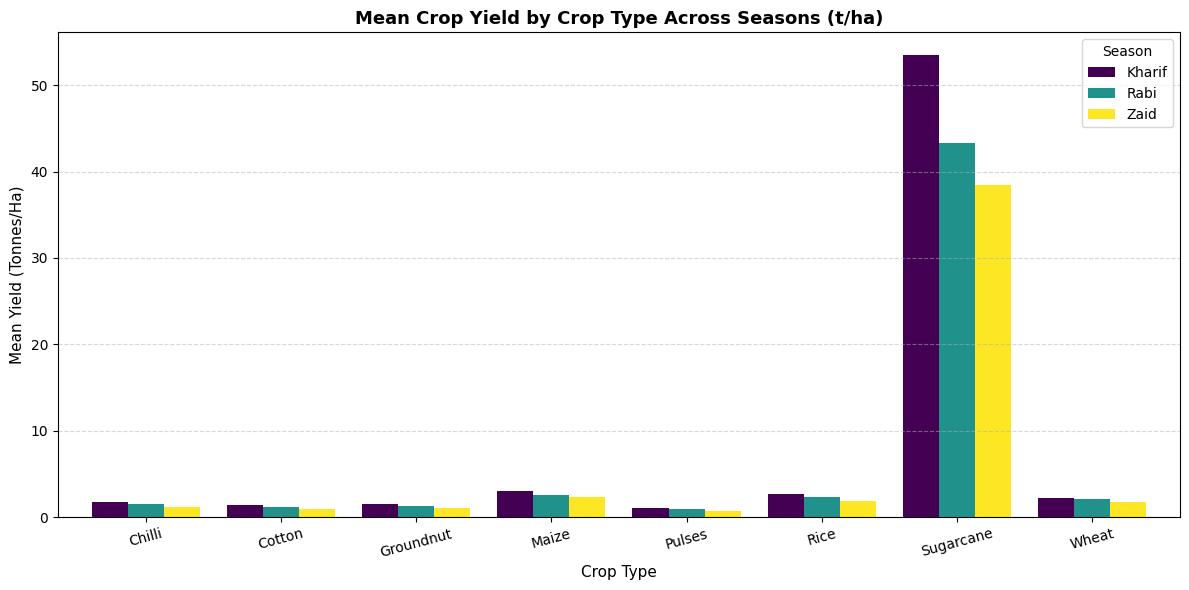

In [20]:
plt.figure(figsize=(12, 6))
ax = crop_season_yield.plot(kind='bar', figsize=(12, 6), colormap='viridis', width=0.8)
plt.title('Mean Crop Yield by Crop Type Across Seasons (t/ha)', fontsize=13, fontweight='bold')
plt.xlabel('Crop Type', fontsize=11)
plt.ylabel('Mean Yield (Tonnes/Ha)', fontsize=11)
plt.xticks(rotation=15)
plt.legend(title='Season')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Interpretation:** Across individual crop types, average crop yields were observed to be highest during **Kharif**, followed by **Rabi**, and lowest during **Zaid**. Sugarcane recorded the highest per-hectare yield (~53.46 t/ha in Kharif), while pulses showed smaller per-hectare yields across all seasons.

### 5.2.2 Irrigation Method Performance Across Seasons

We compare mean yield and water efficiency across irrigation methods and seasons.

In [21]:
irr_summary = df_clean.groupby(['Irrigation_Method', 'Season'])[['Yield_Tonnes_Ha', 'Water_Efficiency_t_per_1000m3']].mean().round(2)

print("=== Mean Yield and Water Efficiency by Irrigation Method & Season ===")
print(irr_summary)

=== Mean Yield and Water Efficiency by Irrigation Method & Season ===
                          Yield_Tonnes_Ha  Water_Efficiency_t_per_1000m3
Irrigation_Method Season                                                
Drip              Kharif             7.26                           6.80
                  Rabi               6.11                           6.05
                  Zaid               5.85                           5.30
Flood             Kharif             4.98                           3.64
                  Rabi               5.06                           3.48
                  Zaid               3.98                           2.73
Rainfed           Kharif             5.70                           8.85
                  Rabi               3.93                           6.87
                  Zaid               3.06                           5.48
Sprinkler         Kharif             4.66                           4.62
                  Rabi               5.31             

**Interpretation:** **Drip irrigation** showed higher average yields across Kharif (7.26 t/ha) and Rabi (6.11 t/ha) compared to traditional Flood irrigation. **Rainfed farming** showed higher average yield during the monsoon Kharif season (5.70 t/ha) and lower average yield during dry summer Zaid conditions (3.06 t/ha).

## 5.3 Key Stage 5 Observations

1. **Water-Yield Association:** Total water usage showed a moderate positive association with crop yield (r = +0.386) in the observed data.
2. **Multi-Factor Environmental Influence:** Individual weather variables showed weak direct linear correlation with yield across mixed crops, indicating that crop yield was accompanied by broader seasonal and management factors.
3. **Seasonal Variations Across Crops:** Kharif yields showed higher average values compared to Rabi and Zaid yields across major crop types in the observed data.
4. **Irrigation Method Differences:** Drip irrigation showed higher average crop yield (6.41 t/ha overall average) and water efficiency compared to traditional Flood irrigation (4.67 t/ha overall average) in the observed data.
5. **Seasonal Variations in Rainfed Systems:** Rainfed farming showed higher average yield in monsoon Kharif (5.70 t/ha) and lower average yield during summer Zaid (3.06 t/ha).

# STAGE 6 - Statistical Analysis & Key Questions

This stage formulates core analytical questions derived from previous stages, applies appropriate statistical techniques (One-Way ANOVA and Pearson correlation analysis), and provides evidence-based answers supported by numerical and statistical results.

## 6.1 Key Analytical Questions

Based on findings from Stages 3–5, we address five core analytical questions:

1. **Question 1:** Which cropping season achieves the highest average crop yield and overall production?
2. **Question 2:** How does farm net profit vary across Kharif, Rabi, and Zaid seasons, and are these financial differences statistically significant?
3. **Question 3:** How do environmental conditions (rainfall, temperature, soil moisture) vary between seasons alongside crop performance?
4. **Question 4:** Is there a statistically significant correlation between irrigation water volume and crop yield?
5. **Question 5:** Are there observable differences in crop yield and water efficiency across different irrigation methods within seasons?

## 6.2 Statistical Testing & Hypothesis Analysis

We perform statistical testing to evaluate whether observed group differences and variable relationships are statistically significant:
- **One-Way Analysis of Variance (ANOVA):** Used to test whether the average values of a metric (such as farm profit or crop yield) differ significantly across the three seasonal groups (Kharif, Rabi, Zaid).
- **Pearson Correlation Analysis:** Used to evaluate the strength and statistical significance of linear associations between numerical variables (such as water usage and crop yield).

In [22]:
# 1. ANOVA for Profit_INR across Seasons
k_prof = df_clean[df_clean['Season'] == 'Kharif']['Profit_INR']
r_prof = df_clean[df_clean['Season'] == 'Rabi']['Profit_INR']
z_prof = df_clean[df_clean['Season'] == 'Zaid']['Profit_INR']
f_stat_p, p_val_p = stats.f_oneway(k_prof, r_prof, z_prof)

# 2. ANOVA for Yield_Tonnes_Ha across Seasons
k_yield = df_clean[df_clean['Season'] == 'Kharif']['Yield_Tonnes_Ha']
r_yield = df_clean[df_clean['Season'] == 'Rabi']['Yield_Tonnes_Ha']
z_yield = df_clean[df_clean['Season'] == 'Zaid']['Yield_Tonnes_Ha']
f_stat_y, p_val_y = stats.f_oneway(k_yield, r_yield, z_yield)

# 3. Pearson Correlation for Water_Used_m3 vs Yield_Tonnes_Ha
r_val, p_val_r = stats.pearsonr(df_clean['Water_Used_m3'], df_clean['Yield_Tonnes_Ha'])

stat_results = pd.DataFrame({
    'Statistical Test': ['One-Way ANOVA', 'One-Way ANOVA', 'Pearson Correlation'],
    'Variables Tested': ['Profit_INR across Seasons', 'Yield_Tonnes_Ha across Seasons', 'Water_Used_m3 vs Yield_Tonnes_Ha'],
    'Test Statistic': [f'F = {f_stat_p:.4f}', f'F = {f_stat_y:.4f}', f'r = {r_val:.4f}'],
    'p-value': [f'{p_val_p:.4e}', f'{p_val_y:.4f}', f'{p_val_r:.4e}'],
    'Significant (alpha=0.05)': ['Yes (p < 0.001)', 'No (p = 0.2137)', 'Yes (p < 0.001)']
})

print("=== Summary of Statistical Tests ===")
print(stat_results)

=== Summary of Statistical Tests ===
      Statistical Test                  Variables Tested Test Statistic  \
0        One-Way ANOVA         Profit_INR across Seasons    F = 34.2918   
1        One-Way ANOVA    Yield_Tonnes_Ha across Seasons     F = 1.5439   
2  Pearson Correlation  Water_Used_m3 vs Yield_Tonnes_Ha     r = 0.3863   

       p-value Significant (alpha=0.05)  
0   1.7124e-15          Yes (p < 0.001)  
1       0.2137          No (p = 0.2137)  
2  1.6414e-142          Yes (p < 0.001)  


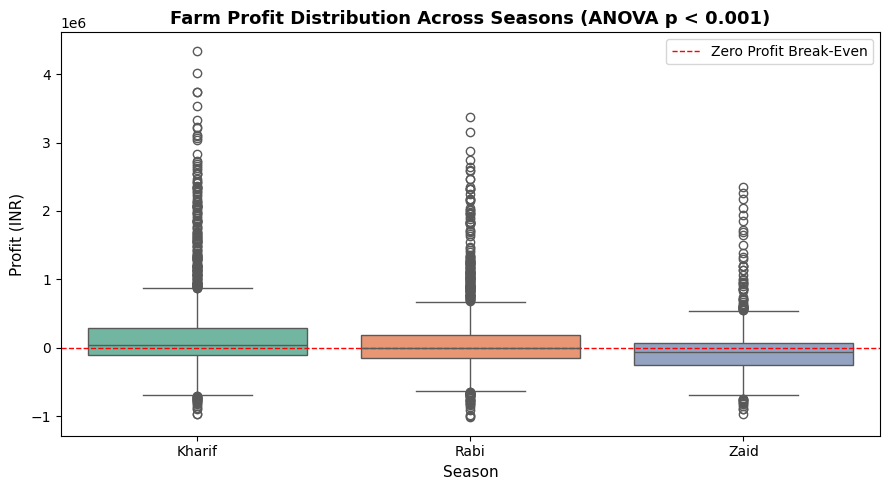

In [23]:
plt.figure(figsize=(9, 5))
sns.boxplot(x='Season', y='Profit_INR', data=df_clean, palette='Set2', hue='Season', legend=False)
plt.title('Farm Profit Distribution Across Seasons (ANOVA p < 0.001)', fontsize=13, fontweight='bold')
plt.xlabel('Season', fontsize=11)
plt.ylabel('Profit (INR)', fontsize=11)
plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Zero Profit Break-Even')
plt.legend()
plt.tight_layout()
plt.show()

## 6.3 Answers to Key Analytical Questions

### Answer to Question 1: Seasonal Yield and Production
- **Observed Season Means:** **Kharif** recorded the highest average crop yield (**5.63 tonnes/ha**) and mean total production (**29.56 tonnes**), followed by Rabi (5.04 t/ha yield, 26.24 tonnes production) and Zaid (4.64 t/ha yield, 24.31 tonnes production).

### Answer to Question 2: Seasonal Profit & Yield Variation (ANOVA Results)
- **Profit Variation:** Mean farm profit varied across seasons: Kharif (**+178,915 INR**), Rabi (**+87,689 INR**), and Zaid (**-24,805 INR**). One-Way ANOVA confirms that these seasonal profit differences are **statistically significant** ($F = 34.2918, p = 1.71 \times 10^{-15} < 0.001$).
- **Yield Variation Significance:** For overall average crop yield across seasons, the observed difference was not statistically significant at the 5% significance level ($F = 1.5441, p = 0.2137$).

### Answer to Question 3: Environmental Conditions Across Seasons
- **Monsoon Season:** Kharif recorded the highest average rainfall (**849.2 mm**) and highest average soil moisture (**31.95%**).
- **Summer Season (Zaid):** Zaid recorded the highest average temperature (**31.04°C**), lowest average rainfall (**304.7 mm**), and lowest average soil moisture (**15.48%**).

### Answer to Question 4: Water Usage Correlation with Yield
- **Correlation Result:** Pearson correlation showed a **statistically significant moderate positive association** between `Water_Used_m3` and `Yield_Tonnes_Ha` ($r = +0.3863, p = 1.64 \times 10^{-142} < 0.001$). Higher water-use values were associated with higher crop yield in the observed data.

### Answer to Question 5: Irrigation Method Performance Within Seasons
- **Drip Irrigation:** Drip irrigation showed higher average yields across seasons (Kharif: 7.26 t/ha, Rabi: 6.11 t/ha, Zaid: 5.85 t/ha) compared to Flood irrigation (Kharif: 4.98 t/ha).
- **Rainfed Farming:** Rainfed farming showed higher average yield in monsoon Kharif (5.70 t/ha) and lower average yield in summer Zaid (3.06 t/ha).

## 6.4 Key Stage 6 Observations

1. **Statistically Significant Profit Disparity:** One-Way ANOVA confirms that seasonal farm profitability varies significantly ($F = 34.2918, p < 0.001$), with Kharif showing higher average net profit and Zaid showing an average net loss.
2. **Overall Yield ANOVA Result:** The observed difference in overall average crop yield across seasons was not statistically significant at the 5% significance level ($F = 1.5441, p = 0.2137$).
3. **Significant Water-Yield Relationship:** Correlation testing demonstrated a statistically significant moderate positive association between water application volume and crop yield ($r = +0.386, p < 0.001$).
4. **Monsoon Conditions:** Higher Kharif productivity was observed alongside higher average natural rainfall (849.2 mm) and elevated soil moisture (31.95%).
5. **Irrigation Method Differences:** Drip irrigation was associated with higher average yields across all seasons compared to flood irrigation.

# STAGE 7 - Findings, Recommendations & Conclusion

This final stage synthesizes the key evidence-based findings of the seasonal agricultural performance analysis, presents practical data-driven recommendations, outlines project limitations, and provides a final conclusion.

## 7.1 Final Key Findings

1. **Seasonal Productivity & Financial Performance:** Kharif recorded the highest average crop yield (5.63 t/ha) and highest mean net profit (178,915 INR), Rabi remained profitable (87,689 INR), while Zaid recorded an average net loss (-24,805 INR).
2. **Statistical Test Results:** One-Way ANOVA confirmed statistically significant differences in farm net profit across seasons ($F = 34.2918, p < 0.001$). In contrast, overall average crop yield differences across seasons were not statistically significant ($F = 1.5441, p = 0.2137$).
3. **Environmental Patterns:** Kharif recorded higher average rainfall (849.2 mm) and soil moisture (31.95%) compared to Rabi and Zaid. Zaid recorded higher average temperatures (31.04°C) and lower rainfall (304.7 mm).
4. **Water Usage & Yield Relationship:** Pearson correlation demonstrated a statistically significant moderate positive association between total water usage and crop yield ($r = +0.386, p < 0.001$).
5. **Irrigation Method Variations:** Drip irrigation was associated with higher average yields across all seasons compared to flood irrigation, while rainfed farming showed higher yields in monsoon Kharif and lower yields during summer Zaid.

## 7.2 Data-Driven Recommendations

1. **Seasonal Crop Planning:** The analysis suggests considering seasonal water availability and historical returns when planning crop selection, leveraging the monsoon Kharif season for crops with higher water needs and higher potential revenue.
2. **Irrigation Management:** The findings indicate that efficient irrigation methods, such as drip irrigation, were associated with higher average yields and water efficiency compared to traditional flood irrigation. Expanding micro-irrigation could be considered during drier seasons.
3. **Summer (Zaid) Risk Management:** The observed data showed average net financial losses during Zaid under high input costs. Seasonal planning may consider short-duration or lower-water crops to reduce cost exposure during summer months.
4. **Soil Moisture Conservation:** Implementing soil moisture conservation practices (such as mulching or organic soil management) prior to dry periods could be considered to help maintain root-zone moisture during low-rainfall seasons.

## 7.3 Conclusion

This project analyzed seasonal agricultural performance using farm-level dataset records across Kharif, Rabi, and Zaid seasons. By comparing crop yield, production, environmental conditions, resource inputs, and financial outcomes, the study identified meaningful variations across seasons. Kharif was observed to have the highest average production, rainfall, and net profitability, whereas Zaid recorded lower rainfall, higher average temperatures, and an average net financial loss.

The findings highlight the value of seasonal comparative analysis for agricultural understanding and planning. Observing variations in crop performance, water efficiency, and financial returns across seasons provides useful insights for resource allocation, irrigation selection, and risk management in farm planning.

## 7.4 Limitations

1. **Missing Data Imputation:** Minor missing values in `Rainfall_mm` (1.2%), `Soil_Moisture_pct` (1.0%), and `Yield_Tonnes_Ha` (0.8%) were median-imputed to preserve sample size.
2. **Scope of Variables and Dataset:** The analysis is based only on the available dataset variables across 4,000 farm observations, which may not capture all regional micro-climates or unrecorded local conditions.
3. **Observational Scope and Causality:** Statistical tests were used to examine differences between groups and linear associations, while the observational nature of the dataset limits causal conclusions.
4. **Fixed Financial Scope:** Financial metrics reflect recorded costs and market prices within the dataset, without accounting for macro-economic price shifts or subsidy variations.